## IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import os
import sys
import duckdb
from traj_ps.backends.bayes import BayesianTrajPS, BayesConfig
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, classification_report, confusion_matrix
)
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from scipy.stats import wilcoxon
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Import shared notebook utilities
sys.path.insert(0, os.path.abspath('.'))
from notebook_utils import (
    aggregate_vitals_labs, drop_high_missing_columns, impute_features,
    plot_trajectory_distribution, plot_boxplots_with_stats, 
    plot_roc_pr_curves, print_statistical_comparisons
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")
print("✓ Shared utilities loaded")

WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


✓ Imports successful
✓ Shared utilities loaded


## LOAD

In [2]:
# Connect to MIMIC-III DuckDB
db_path = '../../data/mimic/mimiciii.duckdb'
conn = duckdb.connect(db_path, read_only=True)

print(f"✓ Connected to MIMIC-III database: {db_path}")

✓ Connected to MIMIC-III database: ../../data/mimic/mimiciii.duckdb


In [3]:
# Load ICU stays with sepsis criteria (Sepsis-3: suspected infection + SOFA ≥2)
# We'll identify sepsis patients using ICD-9 codes
hadm_query = """
WITH sepsis_patients AS (
    SELECT DISTINCT a.hadm_id
    FROM admissions a
    INNER JOIN diagnoses_icd d ON a.hadm_id = d.hadm_id
    WHERE 
        -- Sepsis ICD-9 codes
        (d.icd9_code LIKE '99591' OR  -- Sepsis
         d.icd9_code LIKE '99592' OR  -- Severe sepsis
         d.icd9_code LIKE '78552')    -- Septic shock
)
SELECT 
    a.subject_id::INTEGER AS subject_id,
    a.hadm_id::INTEGER AS hadm_id,
    a.admittime::TIMESTAMP as admittime,      -- Hospital admission time
    a.dischtime::TIMESTAMP as dischtime,      -- Hospital discharge time
    CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) as los_days,  -- Hospital LOS
    p.gender,
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) as age,
    a.hospital_expire_flag::INT as hospital_expire_flag,
    a.discharge_location
FROM admissions a
INNER JOIN patients p ON a.subject_id = p.subject_id
INNER JOIN sepsis_patients sp ON a.hadm_id = sp.hadm_id
WHERE 
    -- Filter adults
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) BETWEEN 18 AND 90
    -- Minimum hospital stay
    AND CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) >= 2.0
"""

hadm_df = conn.execute(hadm_query).fetchdf()
hadm_df.columns = hadm_df.columns.str.lower()
print(f"\n✓ Loaded {len(hadm_df):,} sepsis ICU admissions")
print(f"  Unique patients: {hadm_df['subject_id'].nunique():,}")
print(f"  Mean hospital LOS: {hadm_df['los_days'].mean():.1f} days")
print(f"  Mortality: {hadm_df['hospital_expire_flag'].mean():.1%}")


✓ Loaded 4,704 sepsis ICU admissions
  Unique patients: 4,131
  Mean hospital LOS: 16.2 days
  Mortality: 28.1%


In [4]:
# Sample subset for faster development 
hadm_subset = hadm_df.sort_values('admittime').drop_duplicates(subset=['subject_id'])['hadm_id'].sample(min(5000, hadm_df['subject_id'].nunique()), random_state=920).tolist()
hadm_df = hadm_df[hadm_df['hadm_id'].isin(hadm_subset)]

print(f"✓ Using {len(hadm_df):,} admissions for analysis")

✓ Using 4,131 admissions for analysis


In [5]:
# Load valid ranges from metadata
vital_meta = pd.read_csv('../../data/mimic/vital_metadata.csv')
labs_meta = pd.read_csv('../../data/mimic/labs_metadata.csv')

vital_items = vital_meta['itemid'].to_list()
lab_items = labs_meta['itemid'].to_list()

print("\n✓ Loaded metadata for value range validation")
print(f"   Vitals: {len(vital_meta)} item IDs")
print(f"   Labs: {len(labs_meta)} item IDs")


✓ Loaded metadata for value range validation
   Vitals: 43 item IDs
   Labs: 27 item IDs


In [6]:
vitals_query = """
SELECT chartevents.subject_id::INTEGER AS subject_id
    , chartevents.hadm_id::INTEGER AS hadm_id
    , chartevents.charttime::TIMESTAMP AS charttime
    , chartevents.itemid::INTEGER AS itemid
    , chartevents.valuenum::DOUBLE AS valuenum
      , admissions.admittime::TIMESTAMP AS admittime
        FROM chartevents
                 INNER JOIN admissions
                            ON chartevents.subject_id = admissions.subject_id
                                AND chartevents.hadm_id = admissions.hadm_id
                                AND chartevents.charttime::TIMESTAMP between
                                   (admissions.admittime::TIMESTAMP)
                                   AND (admissions.dischtime::TIMESTAMP)
                                AND itemid::INTEGER in {itemids}
                                AND chartevents.hadm_id::INTEGER in {hadm_ids}
      -- exclude rows marked as error
      AND chartevents.error::INTEGER IS DISTINCT FROM 1 
"""

vitals_df = conn.execute(vitals_query.format(itemids=vital_items, hadm_ids=hadm_subset)).fetchdf()
vitals_df.columns = vitals_df.columns.str.lower()
print(f"✓ Loaded vitals for {vitals_df['hadm_id'].nunique():,} hospital admissions")

✓ Loaded vitals for 4,103 hospital admissions


In [7]:
labs_query = """
SELECT labevents.subject_id::INTEGER AS subject_id
      , labevents.hadm_id::INTEGER AS hadm_id
      , labevents.charttime::TIMESTAMP AS charttime
      , labevents.itemid::INTEGER AS itemid
      , labevents.valuenum::DOUBLE AS valuenum
      , admissions.admittime::TIMESTAMP AS admittime
FROM labevents
          INNER JOIN admissions
                    ON labevents.subject_id = admissions.subject_id
                        AND labevents.hadm_id = admissions.hadm_id
                        AND labevents.charttime::TIMESTAMP between
                            (admissions.admittime::TIMESTAMP)
                            AND (admissions.dischtime::TIMESTAMP)
                        AND itemid::INTEGER IN {itemids}
                        AND labevents.hadm_id::INTEGER IN {hadm_ids}
"""

labs_df = conn.execute(labs_query.format(itemids=lab_items, hadm_ids=hadm_subset)).fetchdf()
labs_df.columns = labs_df.columns.str.lower()
print(f"✓ Loaded labs for {labs_df['hadm_id'].nunique():,} hospital admissions")

✓ Loaded labs for 4,125 hospital admissions


In [8]:
# Extract biomarkers for trajectory modeling
lactate_itemids = labs_meta[labs_meta['feature name'] == 'LACTATE']['itemid'].tolist()
wbc_itemids = labs_meta[labs_meta['feature name'] == 'WBC']['itemid'].tolist()
platelet_itemids = labs_meta[labs_meta['feature name'] == 'PLATELET']['itemid'].tolist()

lactate_df = labs_df[labs_df['itemid'].isin(lactate_itemids)].copy()
lactate_df['time_days'] = (lactate_df['charttime'] - lactate_df['admittime']).dt.total_seconds() / 86400.0
lactate_df = lactate_df.rename(columns={'valuenum': 'lactate'})

wbc_df = labs_df[labs_df['itemid'].isin(wbc_itemids)].copy()
wbc_df['time_days'] = (wbc_df['charttime'] - wbc_df['admittime']).dt.total_seconds() / 86400.0
wbc_df = wbc_df.rename(columns={'valuenum': 'wbc'})

platelet_df = labs_df[labs_df['itemid'].isin(platelet_itemids)].copy()
platelet_df['time_days'] = (platelet_df['charttime'] - platelet_df['admittime']).dt.total_seconds() / 86400.0
platelet_df = platelet_df.rename(columns={'valuenum': 'platelet'})

print(f"\n✓ Extracted biomarker time series:")
print(f"  Lactate:  {len(lactate_df):,} measurements ({lactate_df['hadm_id'].nunique():,} admissions)")
print(f"  WBC:      {len(wbc_df):,} measurements ({wbc_df['hadm_id'].nunique():,} admissions)")
print(f"  Platelet: {len(platelet_df):,} measurements ({platelet_df['hadm_id'].nunique():,} admissions)")


✓ Extracted biomarker time series:
  Lactate:  40,998 measurements (3,701 admissions)
  WBC:      82,583 measurements (4,123 admissions)
  Platelet: 86,387 measurements (4,123 admissions)


# PREPROCESS

In [9]:
# Use shared utility function for standardized vitals/labs aggregation
vitals_labs_pivot = aggregate_vitals_labs(
    vitals_df=vitals_df,
    labs_df=labs_df,
    vital_meta=vital_meta,
    labs_meta=labs_meta
)


print(f"\n✓ Processed vitals + labs with min/max/mean aggregation (using shared utilities):")
print(f"  Total daily observations: {len(vitals_labs_pivot):,}")
print(f"  Total features: {len([c for c in vitals_labs_pivot.columns])}")
print(f"  Example features: {list(vitals_labs_pivot.columns[2:8])}")


✓ Processed vitals + labs with min/max/mean aggregation (using shared utilities):
  Total daily observations: 68,459
  Total features: 87
  Example features: ['BICARBONATE_min', 'BILIRUBIN_min', 'BUN_min', 'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min']


In [10]:
# ffill imputation
vitals_labs_imputed = vitals_labs_pivot.groupby('hadm_id').ffill()

# Special handling for Weight - use both forward and backward fill
vitals_labs_imputed['Weight_mean'] = vitals_labs_imputed.groupby('hadm_id')['Weight_mean'].bfill()


# Use shared utility function for dropping high-missing columns
vitals_labs_clean, dropped_cols = drop_high_missing_columns(
    df=vitals_labs_imputed,
    threshold=0.2,
)

vitals_labs_clean = vitals_labs_clean.reset_index().drop(columns=['admittime'])

hadm_df['admittime'] = pd.to_datetime(hadm_df['admittime'])

hadm_final = hadm_df.merge(vitals_labs_clean, on=['hadm_id'], how='inner')
hadm_final['time_day'] = ((hadm_final['charttime'] - hadm_final['admittime']).dt.total_seconds() / 86400.0).astype(int)

print(f"\n✓ Imputation and cleanup (using shared utilities):")
print(f"  Dropped {len(dropped_cols)} high-missing columns (>20%)")
print(f"  Remaining features: {len([c for c in vitals_labs_clean.columns])}")
print(f"  Overall missing rate: {vitals_labs_clean.drop(columns=['hadm_id']).isna().mean().mean():.2%}")

# Store for later merging
vitals_labs_imputed = vitals_labs_clean


✓ Imputation and cleanup (using shared utilities):
  Dropped 3 high-missing columns (>20%)
  Remaining features: 86
  Overall missing rate: 5.86%


In [11]:
dropped_cols

['ALBUMIN_min', 'ALBUMIN_max', 'ALBUMIN_mean']

In [11]:
# calculate baseline values (first 6 hours)
first_6h_lactate = lactate_df[lactate_df['charttime'] <= lactate_df['admittime'] + pd.Timedelta(hours=6)]
baseline_lactate = first_6h_lactate.sort_values('charttime').pivot_table(
    index='hadm_id',
    values='lactate',
    aggfunc='first'
).reset_index().rename(columns={'lactate': 'baseline_lactate'})

first_6h_wbc = wbc_df[wbc_df['charttime'] <= wbc_df['admittime'] + pd.Timedelta(hours=6)]
baseline_wbc = first_6h_wbc.sort_values('charttime').pivot_table(
    index='hadm_id',
    values='wbc',
    aggfunc='first'
).reset_index().rename(columns={'wbc': 'baseline_wbc'})

first_6h_platelet = platelet_df[platelet_df['charttime'] <= platelet_df['admittime'] + pd.Timedelta(hours=6)]
baseline_platelet = first_6h_platelet.sort_values('charttime').pivot_table(
    index='hadm_id',
    values='platelet',
    aggfunc='first'
).reset_index().rename(columns={'platelet': 'baseline_platelet'})

print(f"\n Baseline Lactate (first 6h):")
print(f"   Admissions with baseline: {len(baseline_lactate):,}")
print(f"   Mean: {baseline_lactate['baseline_lactate'].mean():.2f} mmol/L")
print(f"   Median: {baseline_lactate['baseline_lactate'].median():.2f} mmol/L")

print(f"\n Baseline WBC (first 6h):")
print(f"   Admissions: {len(baseline_wbc):,}")
print(f"   Mean: {baseline_wbc['baseline_wbc'].mean():.1f} K/μL")

print(f"\n Baseline Platelet (first 6h):")
print(f"   Admissions: {len(baseline_platelet):,}")
print(f"   Mean: {baseline_platelet['baseline_platelet'].mean():.0f} K/μL")


 Baseline Lactate (first 6h):
   Admissions with baseline: 1,984
   Mean: 2.61 mmol/L
   Median: 2.00 mmol/L

 Baseline WBC (first 6h):
   Admissions: 2,455
   Mean: 14.6 K/μL

 Baseline Platelet (first 6h):
   Admissions: 2,480
   Mean: 221 K/μL


In [12]:
# Filter admissions with sufficient measurements
lactate_counts = lactate_df.groupby('hadm_id').size()
wbc_counts = wbc_df.groupby('hadm_id').size()
platelet_counts = platelet_df.groupby('hadm_id').size()

# Require ≥3 measurements for at least lactate + one other marker
valid_lactate = lactate_counts[lactate_counts >= 3].index
valid_wbc = wbc_counts[wbc_counts >= 3].index
valid_platelet = platelet_counts[platelet_counts >= 3].index

# At least lactate + one other marker
valid_hadm_ids = valid_lactate[
    valid_lactate.isin(valid_wbc) | valid_lactate.isin(valid_platelet)
]

lactate_filtered = lactate_df[lactate_df['hadm_id'].isin(valid_hadm_ids)]
wbc_filtered = wbc_df[wbc_df['hadm_id'].isin(valid_hadm_ids)]
platelet_filtered = platelet_df[platelet_df['hadm_id'].isin(valid_hadm_ids)]

hadm_final = hadm_final[hadm_final['hadm_id'].isin(valid_hadm_ids)].merge(
    baseline_lactate, on='hadm_id', how='inner'
).merge(
    baseline_wbc, on='hadm_id', how='left'
).merge(
    baseline_platelet, on='hadm_id', how='left'
)

print(f"\nFiltering:")
print(f"   Admissions with ≥3 lactate + other markers: {len(hadm_final):,}")
print(f"   With WBC: {hadm_final['baseline_wbc'].notna().sum():,}")
print(f"   With platelets: {hadm_final['baseline_platelet'].notna().sum():,}")


Filtering:
   Admissions with ≥3 lactate + other markers: 26,523
   With WBC: 18,957
   With platelets: 19,200


In [13]:
# Create time series for all biomarkers
lactate_filtered['time_day'] = np.floor(lactate_filtered['time_days']).astype(int)
wbc_filtered['time_day'] = np.floor(wbc_filtered['time_days']).astype(int)
platelet_filtered['time_day'] = np.floor(platelet_filtered['time_days']).astype(int)

lactate_ts = lactate_filtered[['subject_id', 'hadm_id', 'time_days', 'time_day', 'lactate']].merge(
    hadm_final[['hadm_id', 'baseline_lactate', 'age', 'gender', 'hospital_expire_flag']].drop_duplicates(),
    on='hadm_id',
    how='left'
)

wbc_ts = wbc_filtered[['subject_id', 'hadm_id', 'time_days', 'time_day', 'wbc']].merge(
    hadm_final[['hadm_id', 'baseline_wbc']].drop_duplicates(),
    on='hadm_id',
    how='left'
)

platelet_ts = platelet_filtered[['subject_id', 'hadm_id', 'time_days', 'time_day', 'platelet']].merge(
    hadm_final[['hadm_id', 'baseline_platelet']].drop_duplicates(),
    on='hadm_id',
    how='left'
)

print(f"\nTime Series Created:")
print(f"   Lactate:  {len(lactate_ts):,} measurements")
print(f"   WBC:      {len(wbc_ts):,} measurements")
print(f"   Platelet: {len(platelet_ts):,} measurements")


Time Series Created:
   Lactate:  39,624 measurements
   WBC:      69,581 measurements
   Platelet: 73,134 measurements


In [14]:
# Save preprocessed data
os.makedirs('../../results/mimic/sepsis', exist_ok=True)
lactate_ts.to_csv('../../results/mimic/sepsis/lactate_timeseries.csv', index=False)
wbc_ts.to_csv('../../results/mimic/sepsis/wbc_timeseries.csv', index=False)
platelet_ts.to_csv('../../results/mimic/sepsis/platelet_timeseries.csv', index=False)
hadm_final.to_csv('../../results/mimic/sepsis/hadm_cohort.csv', index=False)

print(f"\n✓ Saved preprocessed data (3 biomarkers)")


✓ Saved preprocessed data (3 biomarkers)


## TRAJ PROBS

**Note**: Run `sepsis_trajs.py` script to compute trajectory probabilities using Bayesian modeling for **multiple biomarkers**:

**Lactate** (primary sepsis marker):
- `window=3.0 days`, `flat_thr=0.1`, `incline_thr=0.3`
- INCREASES = worsening

**WBC** (infection/inflammation):
- `window=3.0 days`, `flat_thr=1.0`, `incline_thr=3.0`
- Can increase (infection) or decrease (immunosuppression)

**Platelets** (organ dysfunction):
- `window=3.0 days`, `flat_thr=20`, `decline_thr=-50`
- DECREASES = worsening (thrombocytopenia)

In [14]:
# Load trajectory probabilities for all biomarkers (after running sepsis_trajs.py)
lactate_traj = pd.read_csv('../../results/mimic/sepsis/lactate_trajectory_probs_bayes.csv')
wbc_traj = pd.read_csv('../../results/mimic/sepsis/wbc_trajectory_probs_bayes.csv')
platelet_traj = pd.read_csv('../../results/mimic/sepsis/platelet_trajectory_probs_bayes.csv')

print(f"✓ Loaded trajectory probabilities:")
print(f"   Lactate:  {len(lactate_traj):,} timepoints")
print(f"   WBC:      {len(wbc_traj):,} timepoints")
print(f"   Platelet: {len(platelet_traj):,} timepoints")

# Merge all trajectories on a common timepoint grid
# Use lactate as base (primary marker)
trajectory_probs = lactate_traj[['hadm_id', 'time_day', 'subject_id', 'lactate', 'baseline_lactate',
                                   'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase']].rename(
    columns={
        'prob_stable': 'lactate_stable',
        'prob_gradual_increase': 'lactate_gradual_increase',
        'prob_rapid_increase': 'lactate_rapid_increase'
    }
)

# Add WBC trajectories
trajectory_probs = trajectory_probs.merge(
    wbc_traj[['hadm_id', 'time_day', 'wbc', 'baseline_wbc',
              'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase']].rename(
        columns={
            'prob_stable': 'wbc_stable',
            'prob_gradual_increase': 'wbc_gradual_increase',
            'prob_rapid_increase': 'wbc_rapid_increase'
        }
    ),
    on=['hadm_id', 'time_day'],
    how='left'
)

# Add platelet trajectories
trajectory_probs = trajectory_probs.merge(
    platelet_traj[['hadm_id', 'time_day', 'platelet', 'baseline_platelet',
                   'prob_stable', 'prob_gradual_increase', 'prob_rapid_increase']].rename(
        columns={
            'prob_stable': 'platelet_stable',
            'prob_gradual_increase': 'platelet_gradual_decline',  # DECLINE for platelets
            'prob_rapid_increase': 'platelet_rapid_decline'
        }
    ),
    on=['hadm_id', 'time_day'],
    how='left'
)

print(f"\n✓ Combined trajectory dataset: {len(trajectory_probs):,} timepoints")
print(f"   Total features: {len(trajectory_probs.columns)}")
print(f"   Trajectory coverage:\n {trajectory_probs[['lactate_stable', 'wbc_stable', 'platelet_stable']].isna().mean()}")

✓ Loaded trajectory probabilities:
   Lactate:  10,546 timepoints
   WBC:      12,172 timepoints
   Platelet: 14,099 timepoints

✓ Combined trajectory dataset: 10,546 timepoints
   Total features: 18
   Trajectory coverage:
 lactate_stable     0.000000
wbc_stable         0.488337
platelet_stable    0.461597
dtype: float64



✓ Saved: lactate_trajectory_distribution.png


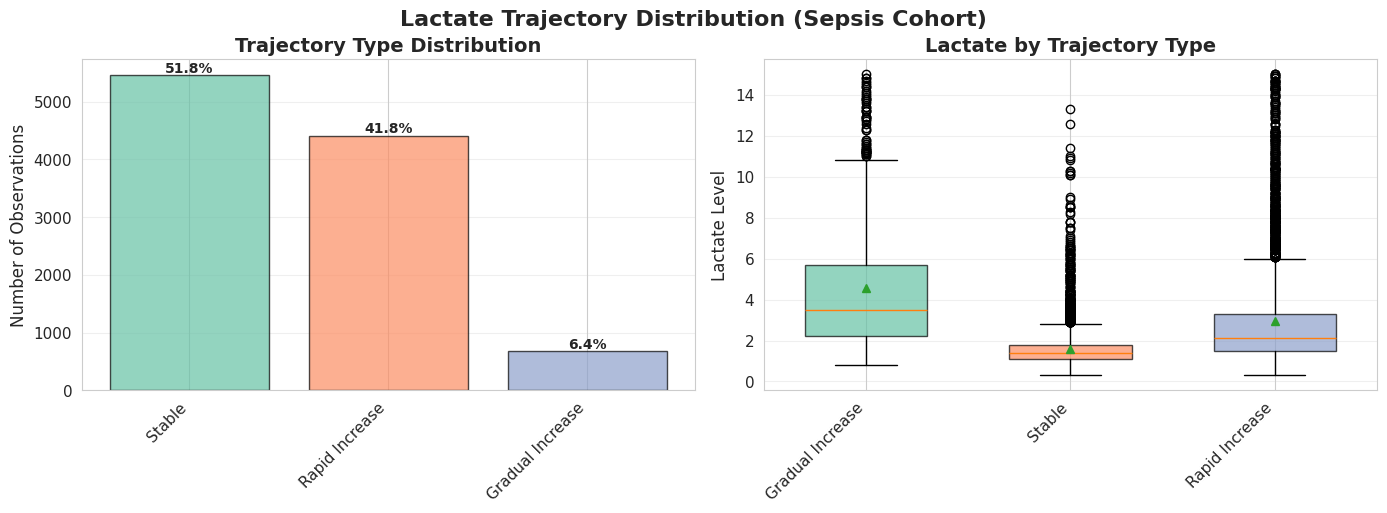

✓ Saved: platelet_trajectory_distribution.png


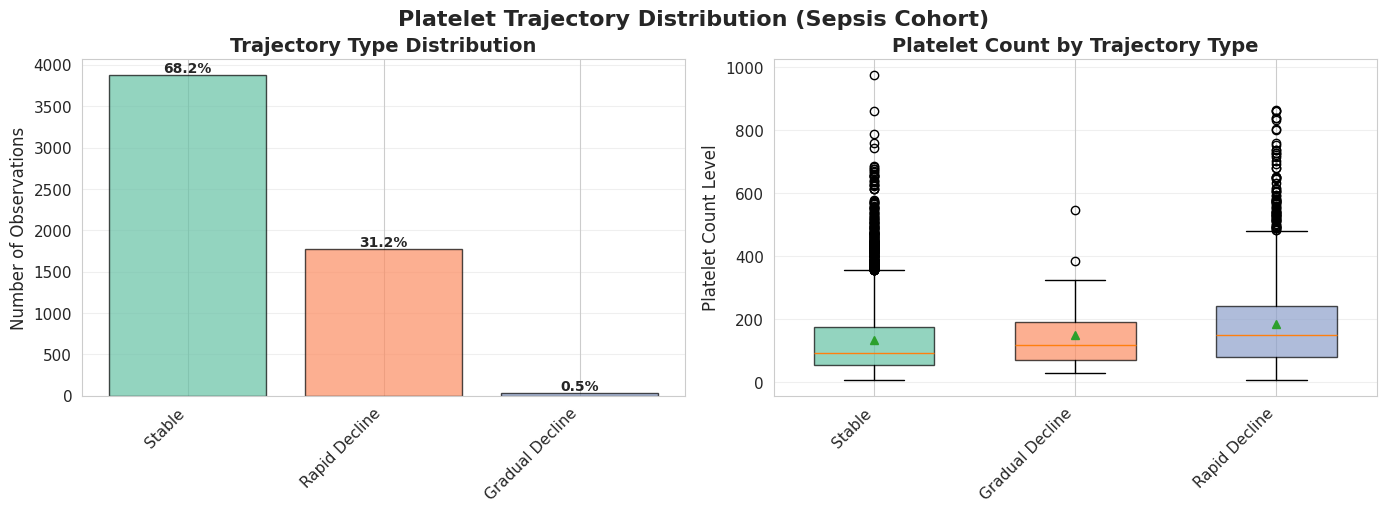

In [26]:
# Visualize trajectory type distributions (using shared utility)
# Determine dominant trajectory for each biomarker
trajectory_probs['dominant_lactate_traj'] = trajectory_probs[[
    'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase'
]].idxmax(axis=1).str.replace('lactate_', '')

trajectory_probs['dominant_wbc_traj'] = trajectory_probs[[
    'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase'
]].idxmax(axis=1).str.replace('wbc_', '')

trajectory_probs['dominant_platelet_traj'] = trajectory_probs[[
    'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline'
]].idxmax(axis=1).str.replace('platelet_', '')

# Visualize lactate trajectories
fig, axes = plot_trajectory_distribution(
    df=trajectory_probs.dropna(subset=['lactate']),
    traj_col='dominant_lactate_traj',
    biomarker_col='lactate',
    biomarker_name='Lactate'
)
plt.suptitle('Lactate Trajectory Distribution (Sepsis Cohort)', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../../results/mimic/sepsis/lactate_trajectory_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: lactate_trajectory_distribution.png")
plt.show()

# Visualize platelet trajectories
fig, axes = plot_trajectory_distribution(
    df=trajectory_probs.dropna(subset=['platelet']),
    traj_col='dominant_platelet_traj',
    biomarker_col='platelet',
    biomarker_name='Platelet Count'
)
plt.suptitle('Platelet Trajectory Distribution (Sepsis Cohort)', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../../results/mimic/sepsis/platelet_trajectory_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: platelet_trajectory_distribution.png")
plt.show()

## STANDARD TRAJ FEATURES

In [15]:
# for 3 days lookback window generate biomarkers summary statistics
LOOKBACK_DAYS = 3

def biomarker_summary_stats(ts_df, value_col, lookback_days):
    summary_df_list = []
    for group, group_df in ts_df.groupby('hadm_id'):
        group_df = group_df.sort_values('time_days')
        summary_list = []
        for current_time in group_df['time_day'].unique():
            window_start = current_time - lookback_days
            window_data = group_df[
                group_df['time_day'].between(window_start, current_time, inclusive='both')
            ]
            if len(window_data) > 0:
                value_mean = window_data[value_col].mean()
                value_max = window_data[value_col].max()
                value_min = window_data[value_col].min()
                value_change = window_data[value_col].iloc[-1] - window_data[value_col].iloc[0]
                value_linear_trend = np.polyfit(window_data['time_days'], window_data[value_col], 1)[0]
                value_std = window_data[value_col].std()
            else:
                value_mean = np.nan
                value_max = np.nan
                value_min = np.nan
                value_change = np.nan
                value_linear_trend = np.nan
                value_std = np.nan
            summary_list.append({
                'hadm_id': group,
                'time_day': current_time,
                f'{value_col}_mean_{lookback_days}d': value_mean,
                f'{value_col}_max_{lookback_days}d': value_max,
                f'{value_col}_min_{lookback_days}d': value_min,
                f'{value_col}_change_{lookback_days}d': value_change,
                f'{value_col}_linear_trend_{lookback_days}d': value_linear_trend,
                f'{value_col}_std_{lookback_days}d': value_std
            })
        summary_df_list.append(pd.DataFrame(summary_list))
    return pd.concat(summary_df_list, ignore_index=True)

lactate_summary_3d = biomarker_summary_stats(lactate_ts, 'lactate', LOOKBACK_DAYS)
wbc_summary_3d = biomarker_summary_stats(wbc_ts, 'wbc', LOOKBACK_DAYS)
platelet_summary_3d = biomarker_summary_stats(platelet_ts, 'platelet', LOOKBACK_DAYS)

In [17]:
lactate_summary_3d.to_csv('../../results/mimic/sepsis/lactate_summary_3d.csv', index=False)
wbc_summary_3d.to_csv('../../results/mimic/sepsis/wbc_summary_3d.csv', index=False)
platelet_summary_3d.to_csv('../../results/mimic/sepsis/platelet_summary_3d.csv', index=False)

## DEFINE OUTCOME

**Outcome**: Septic Shock (within 48h prediction window)
- Lactate ≥ 4 mmol/L AND vasopressor requirement
- OR 28-day mortality (severe outcome proxy)

In [16]:
# Detect vasopressor use
vasopressor_query = """
SELECT DISTINCT
    a.hadm_id::INT as hadm_id,
    MIN(EXTRACT(EPOCH FROM (ie.starttime::timestamp - a.admittime::timestamp)) / 86400) as vaso_start_day
FROM inputevents_mv ie
INNER JOIN admissions a ON ie.hadm_id = a.hadm_id
WHERE 
    ie.itemid IN (30047, 30120, 221906, 221289, 30044, 30119, 30309)  -- Vasopressors
    AND a.hadm_id::INT IN {hadm_ids}
GROUP BY a.hadm_id
"""

vasopressor_df = conn.execute(vasopressor_query.format(hadm_ids=tuple(hadm_final['hadm_id']))).fetchdf()
vasopressor_df.columns = vasopressor_df.columns.str.lower()
print(f"✓ Detected vasopressors in {len(vasopressor_df):,} admissions")

✓ Detected vasopressors in 552 admissions


In [17]:
hadm_final.columns

Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'los_days', 'gender',
       'age', 'hospital_expire_flag', 'discharge_location', 'charttime',
       'ANION GAP_min', 'BICARBONATE_min', 'BILIRUBIN_min', 'BUN_min',
       'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min', 'GLUCOSE_min',
       'Glucose_min', 'HEMATOCRIT_min', 'HEMOGLOBIN_min', 'HeartRate_min',
       'INR_min', 'LACTATE_min', 'MAGNESIUM_min', 'MeanBP_min',
       'PHOSPHATE_min', 'PLATELET_min', 'POTASSIUM_min', 'PT_min', 'PTT_min',
       'RespRate_min', 'SODIUM_min', 'SpO2_min', 'SysBP_min', 'TempC_min',
       'WBC_min', 'Weight_min', 'ANION GAP_max', 'BICARBONATE_max',
       'BILIRUBIN_max', 'BUN_max', 'CHLORIDE_max', 'CREATININE_max',
       'DiasBP_max', 'GLUCOSE_max', 'Glucose_max', 'HEMATOCRIT_max',
       'HEMOGLOBIN_max', 'HeartRate_max', 'INR_max', 'LACTATE_max',
       'MAGNESIUM_max', 'MeanBP_max', 'PHOSPHATE_max', 'PLATELET_max',
       'POTASSIUM_max', 'PT_max', 'PTT_max', 'RespRate_max', 'SODIUM_

In [18]:
hadm_final = hadm_final.drop_duplicates(subset=['hadm_id', 'time_day'])

In [19]:
hadm_final['hadm_id'] = hadm_final['hadm_id'].astype(np.int32)

In [22]:
lactate_ts.dtypes

subject_id                int32
hadm_id                   int32
time_days               float64
time_day                  int64
lactate                 float64
baseline_lactate        float64
age                     float64
gender                   object
hospital_expire_flag    float64
dtype: object

In [20]:
# Define septic shock outcome with prediction gap
PREDICTION_GAP_DAYS = 0.5   # 12 hours gap
PREDICTION_WINDOW_DAYS = 2.0  # 48 hours prediction window

print(f"Prediction Configuration:")
print(f"   Gap:    {PREDICTION_GAP_DAYS} days")
print(f"   Window: {PREDICTION_WINDOW_DAYS} days")
print(f"   Total:  {PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS} days lookahead")

septic_shock_events = []
n_at_shock = 0
n_no_data = 0

for hadm_id, grp in hadm_final.groupby('hadm_id'):
    grp = grp.sort_values('time_day')
    mortality = hadm_final[hadm_final['hadm_id'] == hadm_id]['hospital_expire_flag'].iloc[0]
    
    for i in range(len(grp)):
        current_time = grp.iloc[i]['time_day']
        current_lactate = grp.iloc[i]['LACTATE_mean']
        
        # Skip if already in shock
        if current_lactate >= 4.0:
            n_at_shock += 1
            continue
        
        # Define prediction window
        prediction_start = current_time + PREDICTION_GAP_DAYS + 1
        prediction_end = current_time + PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS + 1
        
        future_window = lactate_ts[(lactate_ts['hadm_id'] == hadm_id) & (lactate_ts['time_days'].between(prediction_start, prediction_end, inclusive='both'))]
        
        
        if len(future_window) == 0:
            n_no_data += 1
            continue
        
        # Septic shock criteria
        high_lactate = (future_window['lactate'] >= 4.0).any()
        
        # Check vasopressor in window
        vasopressor_in_window = False
        if hadm_id in vasopressor_df['hadm_id'].values:
            vaso_start = vasopressor_df[vasopressor_df['hadm_id'] == hadm_id]['vaso_start_day'].iloc[0]
            vasopressor_in_window = (prediction_start <= vaso_start <= prediction_end)
        
        # Combined outcome: (high lactate + vasopressor) OR mortality
        target = int((high_lactate and vasopressor_in_window) or mortality)
        
        septic_shock_events.append({
            'hadm_id': hadm_id,
            'time_day': current_time,
            'target_septic_shock': target,
            'current_lactate': current_lactate
        })

outcome_df = pd.DataFrame(septic_shock_events)

# CRITICAL: For each patient, keep all negative windows but only the FIRST positive event
# This ensures we predict the first occurrence of septic shock
outcome_df = outcome_df.sort_values(['hadm_id', 'time_day'])
positive_first = outcome_df[outcome_df['target_septic_shock'] == 1].groupby('hadm_id').first().reset_index()
all_negatives = outcome_df[outcome_df['target_septic_shock'] == 0]
outcome_df = pd.concat([all_negatives, positive_first], ignore_index=True).sort_values(['hadm_id', 'time_day']).reset_index(drop=True)

print(f"\nOutcome Definition:")
print(f"   Total prediction windows: {len(outcome_df):,}")
print(f"   Unique patients: {outcome_df['hadm_id'].nunique():,}")
print(f"   Septic shock events (first per patient): {outcome_df['target_septic_shock'].sum():,}")
print(f"   Event rate: {outcome_df['target_septic_shock'].mean():.1%}")
print(f"   Avg windows/patient: {len(outcome_df) / outcome_df['hadm_id'].nunique():.1f}")
print(f"   Skipped (already in shock): {n_at_shock:,}")
print(f"   Skipped (no future data): {n_no_data:,}")


Prediction Configuration:
   Gap:    0.5 days
   Window: 2.0 days
   Total:  2.5 days lookahead

Outcome Definition:
   Total prediction windows: 5,090
   Unique patients: 1,175
   Septic shock events (first per patient): 414
   Event rate: 8.1%
   Avg windows/patient: 4.3
   Skipped (already in shock): 1,126
   Skipped (no future data): 16,453


## FIT MODELS

Compare models with different feature sets:
1. Lactate Trajectory Only
2. Multi-Marker Trajectories (Lactate + WBC + Platelets)
3. Static Only (demographics + baseline values)
4. **Traj + Static + Dynamic** (comprehensive clinical model with vitals, labs, and organ dysfunction flags)

In [36]:
hadm_final.columns

Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'los_days', 'gender',
       'age', 'hospital_expire_flag', 'discharge_location', 'charttime',
       'ANION GAP_min', 'BICARBONATE_min', 'BILIRUBIN_min', 'BUN_min',
       'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min', 'GLUCOSE_min',
       'Glucose_min', 'HEMATOCRIT_min', 'HEMOGLOBIN_min', 'HeartRate_min',
       'INR_min', 'LACTATE_min', 'MAGNESIUM_min', 'MeanBP_min',
       'PHOSPHATE_min', 'PLATELET_min', 'POTASSIUM_min', 'PT_min', 'PTT_min',
       'RespRate_min', 'SODIUM_min', 'SpO2_min', 'SysBP_min', 'TempC_min',
       'WBC_min', 'Weight_min', 'ANION GAP_max', 'BICARBONATE_max',
       'BILIRUBIN_max', 'BUN_max', 'CHLORIDE_max', 'CREATININE_max',
       'DiasBP_max', 'GLUCOSE_max', 'Glucose_max', 'HEMATOCRIT_max',
       'HEMOGLOBIN_max', 'HeartRate_max', 'INR_max', 'LACTATE_max',
       'MAGNESIUM_max', 'MeanBP_max', 'PHOSPHATE_max', 'PLATELET_max',
       'POTASSIUM_max', 'PT_max', 'PTT_max', 'RespRate_max', 'SODIUM_

In [37]:
trajectory_probs.columns

Index(['hadm_id', 'time_day', 'subject_id', 'lactate', 'baseline_lactate',
       'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase',
       'wbc', 'baseline_wbc', 'wbc_stable', 'wbc_gradual_increase',
       'wbc_rapid_increase', 'platelet', 'baseline_platelet',
       'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline',
       'dominant_lactate_traj', 'dominant_wbc_traj', 'dominant_platelet_traj'],
      dtype='object')

In [21]:
# Merge features and prepare dataset
prediction_dataset = outcome_df.merge(
    trajectory_probs[[
        'hadm_id', 'time_day',
        # Lactate trajectories
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase',
        # WBC trajectories
        'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase',
        # Platelet trajectories
        'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline',
        # Current trajectory marker values
        'lactate', 'wbc', 'platelet',
          'baseline_lactate', 'baseline_wbc', 'baseline_platelet']],
    on=['hadm_id', 'time_day'],
    how='left'
)

# Add static features
static_features = hadm_final[[
    'hadm_id', 'age', 'gender']].drop_duplicates()
prediction_dataset = prediction_dataset.merge(static_features, on='hadm_id', how='left')

vitals_labs_features = ['ANION GAP_min', 'BICARBONATE_min', 'BILIRUBIN_min', 'BUN_min',
       'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min', 'GLUCOSE_min',
        'HEMATOCRIT_min', 'HEMOGLOBIN_min', 'HeartRate_min',
       'INR_min',  'LACTATE_min', 'MAGNESIUM_min', 'MeanBP_min',
       'PHOSPHATE_min', 'POTASSIUM_min', 'PT_min', 'PTT_min', 'PLATELET_min',
       'RespRate_min', 'SODIUM_min', 'SpO2_min', 'SysBP_min', 'TempC_min', 'WBC_min',
       'ANION GAP_max', 'BICARBONATE_max',
       'BILIRUBIN_max', 'BUN_max', 'CHLORIDE_max', 'CREATININE_max',
       'DiasBP_max', 'GLUCOSE_max',  'HEMATOCRIT_max',
       'HEMOGLOBIN_max', 'HeartRate_max', 'INR_max', 'LACTATE_max', 
       'MAGNESIUM_max', 'MeanBP_max', 'PHOSPHATE_max', 'PLATELET_max',
       'POTASSIUM_max', 'PT_max', 'PTT_max', 'RespRate_max', 'SODIUM_max',
       'SpO2_max', 'SysBP_max', 'TempC_max', 'WBC_max',
       'ANION GAP_mean', 'BICARBONATE_mean', 'BILIRUBIN_mean', 'BUN_mean',
       'CHLORIDE_mean', 'CREATININE_mean', 'DiasBP_mean', 'GLUCOSE_mean',
        'HEMATOCRIT_mean', 'HEMOGLOBIN_mean', 'HeartRate_mean',
       'INR_mean', 'LACTATE_mean', 'MAGNESIUM_mean', 'MeanBP_mean',
       'PHOSPHATE_mean', 'POTASSIUM_mean', 'PT_mean',
       'PTT_mean', 'PLATELET_mean', 'RespRate_mean', 'SODIUM_mean', 'SpO2_mean', 'SysBP_mean',
       'TempC_mean', 'WBC_mean','Weight_mean']

# Merge vitals and labs
prediction_dataset = prediction_dataset.merge(hadm_final[vitals_labs_features + ['hadm_id', 'time_day']].drop_duplicates(subset=['hadm_id', 'time_day']), on=['hadm_id', 'time_day'], how='left')

# add summary stats for biomarkers
prediction_dataset = prediction_dataset.merge(
    lactate_summary_3d.fillna(0),
    on=['hadm_id', 'time_day'],
    how='left'
).merge(
    wbc_summary_3d.fillna(0),
    on=['hadm_id', 'time_day'],
    how='left'
).merge(
    platelet_summary_3d.fillna(0),
    on=['hadm_id', 'time_day'],
    how='left'
)

# Add derived features
prediction_dataset['lactate_worsening'] = (
    prediction_dataset['lactate_gradual_increase'] + 
    prediction_dataset['lactate_rapid_increase']
)
prediction_dataset['wbc_worsening'] = (
    prediction_dataset['wbc_gradual_increase'] + 
    prediction_dataset['wbc_rapid_increase']
)
prediction_dataset['platelet_worsening'] = (
    prediction_dataset['platelet_gradual_decline'] + 
    prediction_dataset['platelet_rapid_decline']
)

# Combined multi-marker worsening score
prediction_dataset['multi_marker_worsening'] = (
    prediction_dataset['lactate_worsening'].fillna(0) +
    prediction_dataset['wbc_worsening'].fillna(0) +
    prediction_dataset['platelet_worsening'].fillna(0)
) / 3

# Clinical flags
prediction_dataset['lactate_elevated'] = (prediction_dataset['current_lactate'] > 2.0).astype(int)
prediction_dataset['fever'] = (prediction_dataset['TempC_mean'] > 100.4).astype(int)  # >38°C
prediction_dataset['hypothermia'] = (prediction_dataset['TempC_mean'] < 96.8).astype(int)  # <36°C
prediction_dataset['tachycardia'] = (prediction_dataset['HeartRate_mean'] > 90).astype(int)
prediction_dataset['tachypnea'] = (prediction_dataset['RespRate_mean'] > 20).astype(int)
prediction_dataset['hypotension'] = (prediction_dataset['MeanBP_mean'] < 65).astype(int)
prediction_dataset['hypoxemia'] = (prediction_dataset['SpO2_mean'] < 90).astype(int)

# SOFA-like severity score components
prediction_dataset['aki_present'] = (prediction_dataset['CREATININE_mean'] > 1.2).astype(int)
prediction_dataset['coagulopathy'] = (prediction_dataset['INR_mean'] > 1.5).astype(int)
prediction_dataset['liver_dysfunction'] = (prediction_dataset['BILIRUBIN_mean'] > 2.0).astype(int)

print(f"Prediction dataset: {len(prediction_dataset):,} windows")
print(f"Features with all 3 markers: {prediction_dataset[['lactate_worsening', 'wbc_worsening', 'platelet_worsening']].notna().all(axis=1).sum():,}")
print(f"Complete clinical data (traj+vitals+labs): {prediction_dataset[vitals_labs_features].notna().all(axis=1).sum():,}")

Prediction dataset: 5,090 windows
Features with all 3 markers: 999
Complete clinical data (traj+vitals+labs): 4,045


In [22]:
# Define feature sets
feature_sets = {
    'Lactate Trajectory Only': [
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening'
    ],
    'Multi-Marker Trajectories': [
        # Lactate
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening',
        # WBC
        'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase', 'wbc_worsening',
        # Platelet
        'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline', 'platelet_worsening',
        # Combined
        'multi_marker_worsening'
    ],

    'Lactate Summary Stats Only': [
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d'
    ],
    'Multi-Marker Summary Stats': [
        # Lactate
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d',
        # WBC
        'wbc_mean_3d', 'wbc_max_3d', 'wbc_min_3d',
        'wbc_change_3d', 'wbc_linear_trend_3d', 'wbc_std_3d',
        # Platelet
        'platelet_mean_3d', 'platelet_max_3d', 'platelet_min_3d',
        'platelet_change_3d', 'platelet_linear_trend_3d', 'platelet_std_3d'
    ],

    'Lactate Trajectory + Summary Stats': [
        # Trajectories
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening',
        # Summary stats
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d'
    ],
    'Multi-Marker Trajectories + Summary Stats': [
        # Trajectories
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening',
        'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase', 'wbc_worsening',
        'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline', 'platelet_worsening',
        'multi_marker_worsening',
        # Summary stats
        # Lactate
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d',
        # WBC
        'wbc_mean_3d', 'wbc_max_3d', 'wbc_min_3d',
        'wbc_change_3d', 'wbc_linear_trend_3d', 'wbc_std_3d',
        # Platelet
        'platelet_mean_3d', 'platelet_max_3d', 'platelet_min_3d',
        'platelet_change_3d', 'platelet_linear_trend_3d', 'platelet_std_3d'
    ],

    'Static Only': [
        'age', 'gender', 'baseline_lactate', 'current_lactate', 'lactate_elevated'
    ],
    'Static + Lactate Trajectory': [
        'age', 'gender', 'baseline_lactate', 'current_lactate', 'lactate_elevated',
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening'
    ],
    'Static + Multi-Marker Trajectories': [
        'age', 'gender', 'baseline_lactate', 'current_lactate', 'lactate_elevated',
        # Lactate
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening',
        # WBC
        'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase', 'wbc_worsening',
        # Platelet
        'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline', 'platelet_worsening',
        # Combined
        'multi_marker_worsening'
    ],

    'Static + Lactate Summary Stats': [
        'age', 'gender', 'baseline_lactate', 'current_lactate', 'lactate_elevated',
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d'
    ],
    'Static + Multi-Marker Summary Stats': [
        'age', 'gender', 'baseline_lactate', 'current_lactate', 'lactate_elevated',
        # Lactate
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d',
        # WBC
        'wbc_mean_3d', 'wbc_max_3d', 'wbc_min_3d',
        'wbc_change_3d', 'wbc_linear_trend_3d', 'wbc_std_3d',
        # Platelet
        'platelet_mean_3d', 'platelet_max_3d', 'platelet_min_3d',
        'platelet_change_3d', 'platelet_linear_trend_3d', 'platelet_std_3d'
    ],

    'Static + Lactate Trajectory + Summary Stats': [
        'age', 'gender', 'baseline_lactate', 'current_lactate', 'lactate_elevated',
        # Trajectories
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening',
        # Summary stats
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d'
    ],
    'Static + Multi-Marker Trajectories + Summary Stats': [
        'age', 'gender', 'baseline_lactate', 'current_lactate', 'lactate_elevated',
        # Trajectories
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening',
        'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase', 'wbc_worsening',
        'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline', 'platelet_worsening',
        'multi_marker_worsening',
        # Summary stats
        # Lactate
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d',
        # WBC
        'wbc_mean_3d', 'wbc_max_3d', 'wbc_min_3d',
        'wbc_change_3d', 'wbc_linear_trend_3d', 'wbc_std_3d',
        # Platelet
        'platelet_mean_3d', 'platelet_max_3d', 'platelet_min_3d',
        'platelet_change_3d', 'platelet_linear_trend_3d', 'platelet_std_3d'
    ],

    'Static + Dynamic': [
        # Static
        'age', 'gender', 'baseline_lactate', 'lactate_elevated',
        # Clinical flags
        'fever', 'hypothermia', 'tachycardia', 'tachypnea', 'hypotension', 'hypoxemia',
        'aki_present', 'coagulopathy', 'liver_dysfunction'
    ] + vitals_labs_features,
    'Lactate Trajectory + Static + Dynamic': [
        # Lactate Trajectories
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening',
        # Static
        'age', 'gender', 'baseline_lactate', 'lactate_elevated',
        # Clinical flags
        'fever', 'hypothermia', 'tachycardia', 'tachypnea', 'hypotension', 'hypoxemia',
        'aki_present', 'coagulopathy', 'liver_dysfunction'
    ] + vitals_labs_features,
    'Lactate Summary Stats + Static + Dynamic': [
        # Lactate Summary Stats
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d',
        # Static
        'age', 'gender', 'baseline_lactate', 'lactate_elevated',
        # Clinical flags
        'fever', 'hypothermia', 'tachycardia', 'tachypnea', 'hypotension', 'hypoxemia',
        'aki_present', 'coagulopathy', 'liver_dysfunction'
    ] + vitals_labs_features,   
    'Lactate Trajectory + Summary Stats + Static + Dynamic': [
        # Lactate Trajectories
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening',
        # Lactate Summary Stats
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d',
        # Static
        'age', 'gender', 'baseline_lactate', 'lactate_elevated',
        # Clinical flags
        'fever', 'hypothermia', 'tachycardia', 'tachypnea', 'hypotension', 'hypoxemia',
        'aki_present', 'coagulopathy', 'liver_dysfunction'
    ] + vitals_labs_features,
    'Multi-Marker Trajectories + Static + Dynamic': [
        # Trajectories
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening',
        'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase', 'wbc_worsening',
        'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline', 'platelet_worsening',
        'multi_marker_worsening',
        # Static
        'age', 'gender', 'baseline_lactate', 'lactate_elevated',
        # Clinical flags
        'fever', 'hypothermia', 'tachycardia', 'tachypnea', 'hypotension', 'hypoxemia',
        'aki_present', 'coagulopathy', 'liver_dysfunction'
    ] + vitals_labs_features,
    'Multi-Marker Summary Stats + Static + Dynamic': [
        # Summary stats
        # Lactate
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d',
        # WBC
        'wbc_mean_3d', 'wbc_max_3d', 'wbc_min_3d',
        'wbc_change_3d', 'wbc_linear_trend_3d', 'wbc_std_3d',
        # Platelet
        'platelet_mean_3d', 'platelet_max_3d', 'platelet_min_3d',
        'platelet_change_3d', 'platelet_linear_trend_3d', 'platelet_std_3d',
        # Static
        'age', 'gender', 'baseline_lactate', 'lactate_elevated',
        # Clinical flags
        'fever', 'hypothermia', 'tachycardia', 'tachypnea', 'hypotension', 'hypoxemia',
        'aki_present', 'coagulopathy', 'liver_dysfunction'
    ] + vitals_labs_features,
    'Multi-Marker Trajectories + Summary Stats + Static + Dynamic': [
        # Trajectories
        'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase', 'lactate_worsening',
        'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase', 'wbc_worsening',
        'platelet_stable', 'platelet_gradual_decline', 'platelet_rapid_decline', 'platelet_worsening',
        'multi_marker_worsening',
        # Summary stats
        # Lactate
        'lactate_mean_3d', 'lactate_max_3d', 'lactate_min_3d',
        'lactate_change_3d', 'lactate_linear_trend_3d', 'lactate_std_3d',
        # WBC
        'wbc_mean_3d', 'wbc_max_3d', 'wbc_min_3d',
        'wbc_change_3d', 'wbc_linear_trend_3d', 'wbc_std_3d',
        # Platelet
        'platelet_mean_3d', 'platelet_max_3d', 'platelet_min_3d',
        'platelet_change_3d', 'platelet_linear_trend_3d', 'platelet_std_3d',
        # Static
        'age', 'gender', 'baseline_lactate', 'lactate_elevated',
        # Clinical flags
        'fever', 'hypothermia', 'tachycardia', 'tachypnea', 'hypotension', 'hypoxemia',
        'aki_present', 'coagulopathy', 'liver_dysfunction'
    ] + vitals_labs_features
}

for name, features in feature_sets.items():
    print(f"{name:30s}: {len(features):2d} features")

Lactate Trajectory Only       :  4 features
Multi-Marker Trajectories     : 13 features
Lactate Summary Stats Only    :  6 features
Multi-Marker Summary Stats    : 18 features
Lactate Trajectory + Summary Stats: 10 features
Multi-Marker Trajectories + Summary Stats: 31 features
Static Only                   :  5 features
Static + Lactate Trajectory   :  9 features
Static + Multi-Marker Trajectories: 18 features
Static + Lactate Summary Stats: 11 features
Static + Multi-Marker Summary Stats: 23 features
Static + Lactate Trajectory + Summary Stats: 15 features
Static + Multi-Marker Trajectories + Summary Stats: 36 features
Static + Dynamic              : 92 features
Lactate Trajectory + Static + Dynamic: 96 features
Lactate Summary Stats + Static + Dynamic: 98 features
Lactate Trajectory + Summary Stats + Static + Dynamic: 102 features
Multi-Marker Trajectories + Static + Dynamic: 105 features
Multi-Marker Summary Stats + Static + Dynamic: 110 features
Multi-Marker Trajectories + Summary

In [46]:
prediction_dataset.columns

Index(['hadm_id', 'time_day', 'target_septic_shock', 'current_lactate',
       'lactate_stable', 'lactate_gradual_increase', 'lactate_rapid_increase',
       'wbc_stable', 'wbc_gradual_increase', 'wbc_rapid_increase',
       ...
       'lactate_elevated', 'fever', 'hypothermia', 'tachycardia', 'tachypnea',
       'hypotension', 'hypoxemia', 'aki_present', 'coagulopathy',
       'liver_dysfunction'],
      dtype='object', length=105)

In [23]:


# Create prediction_clean by dropping only rows with missing target
prediction_clean = prediction_dataset.dropna(subset=['target_septic_shock']).copy().sort_values(by='time_day')
prediction_clean['gender'] = prediction_clean['gender'].map({'M': 1, 'F': 0})

# Fill missing values intelligently
# Trajectory probabilities: forward fill within patient with limit (recent trajectory state likely persists)
traj_cols = [c for c in prediction_clean.columns if any(x in c for x in ['_stable', '_increase', '_decline', '_worsening'])]
for col in traj_cols:
    if col in prediction_clean.columns:
        # Forward fill up to 2 time windows (carry forward recent trajectory state)
        prediction_clean[col] = prediction_clean.groupby('hadm_id')[col].fillna(method='ffill', limit=2)
        # Remaining NaN values set to 0 (truly unknown, too far from last measurement)
        prediction_clean[col] = prediction_clean[col].fillna(0)


y = prediction_clean['target_septic_shock']
groups = prediction_clean['hadm_id']

print(f"\nDataset:")
print(f"   Total samples: {len(y):,}")
print(f"   Positive class: {y.sum():,} ({y.mean():.1%})")
print(f"   Unique patients: {groups.nunique():,}")
print(f"   Avg trajectories/patient: {len(y) / groups.nunique():.1f}")
print(f"\nImputation strategy:")
print(f"   Trajectories: ffill limit=2 windows, then 0 (recent state persists)")
print(f"   Vitals/Labs:  ffill limit=3 windows (avoid stale data)")
print(f"\nClinical flags prevalence:")
print(f"   Fever/hypothermia: {prediction_clean[['fever', 'hypothermia']].sum().sum():,} ({prediction_clean[['fever', 'hypothermia']].sum().sum()/len(prediction_clean):.1%})")
print(f"   Tachycardia:       {prediction_clean['tachycardia'].sum():,} ({prediction_clean['tachycardia'].mean():.1%})")
print(f"   Hypotension:       {prediction_clean['hypotension'].sum():,} ({prediction_clean['hypotension'].mean():.1%})")
print(f"   Organ dysfunction: {prediction_clean[['aki_present', 'coagulopathy', 'liver_dysfunction']].sum().sum():,}")



Dataset:
   Total samples: 5,090
   Positive class: 414 (8.1%)
   Unique patients: 1,175
   Avg trajectories/patient: 4.3

Imputation strategy:
   Trajectories: ffill limit=2 windows, then 0 (recent state persists)
   Vitals/Labs:  ffill limit=3 windows (avoid stale data)

Clinical flags prevalence:
   Fever/hypothermia: 4,913 (96.5%)
   Tachycardia:       2,577 (50.6%)
   Hypotension:       491 (9.6%)
   Organ dysfunction: 5,166


In [24]:
# Cross-validation training with multiple randomized splits
N_REPEATS = 10  # Number of repeated CV runs with different random splits
N_FOLDS = 5

comparison_results = {}

print(f"Training models with {N_REPEATS} repeated {N_FOLDS}-fold CV:\n")

for feature_set_name, feature_cols in feature_sets.items():
    print(f"{feature_set_name}")
    print("-" * 60)
    
    X = prediction_clean[feature_cols]
    
    fold_metrics = {
        'roc_auc': [], 'avg_precision': [],
        'y_true': [], 'y_proba': [],
        'fold_roc_curves': [], 'fold_pr_curves': []
    }
    
    # Repeat CV with different random splits
    for repeat in range(N_REPEATS):
        gkf = GroupKFold(n_splits=N_FOLDS)
        
        # Shuffle groups for each repeat
        shuffled_df = prediction_clean.sample(frac=1, random_state=920 + repeat * 37)
        X_shuffled = shuffled_df[feature_cols]
        y_shuffled = shuffled_df['target_septic_shock']
        groups_shuffled = shuffled_df['hadm_id']
        
        
        
        for train_idx, test_idx in gkf.split(X_shuffled, y_shuffled, groups_shuffled):
            scaler = StandardScaler()
            X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
            
            # Median impute by X_train medians
            for col in X_train.columns:
                impute_val = X_train[col].median()
                X_train[col] = X_train[col].fillna(impute_val)
                X_test[col] = X_test[col].fillna(impute_val)

            X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
            X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
            
            y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

            model = XGBClassifier(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.1,
            scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
            random_state=920 + repeat
        )
            
            model.fit(X_train, y_train)
            y_proba = model.predict_proba(X_test)[:, 1]
            
            if y_test.sum() > 0:
                fold_metrics['roc_auc'].append(roc_auc_score(y_test, y_proba))
                fold_metrics['avg_precision'].append(average_precision_score(y_test, y_proba))
                
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                fold_metrics['fold_roc_curves'].append((fpr, tpr))
                
                precision, recall, _ = precision_recall_curve(y_test, y_proba)
                fold_metrics['fold_pr_curves'].append((recall, precision))
            
            fold_metrics['y_true'].extend(y_test.values)
            fold_metrics['y_proba'].extend(y_proba)
    
    comparison_results[feature_set_name] = fold_metrics
    
    print(f"  AUROC: {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f} (n={len(fold_metrics['roc_auc'])} folds)")
    print(f"  AUPR:  {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f} (n={len(fold_metrics['avg_precision'])} folds)\n")


Training models with 10 repeated 5-fold CV:

Lactate Trajectory Only
------------------------------------------------------------
  AUROC: 0.757 ± 0.027 (n=50 folds)
  AUPR:  0.216 ± 0.041 (n=50 folds)

Multi-Marker Trajectories
------------------------------------------------------------
  AUROC: 0.784 ± 0.021 (n=50 folds)
  AUPR:  0.238 ± 0.036 (n=50 folds)

Lactate Summary Stats Only
------------------------------------------------------------
  AUROC: 0.790 ± 0.017 (n=50 folds)
  AUPR:  0.276 ± 0.029 (n=50 folds)

Multi-Marker Summary Stats
------------------------------------------------------------
  AUROC: 0.827 ± 0.022 (n=50 folds)
  AUPR:  0.298 ± 0.043 (n=50 folds)

Lactate Trajectory + Summary Stats
------------------------------------------------------------
  AUROC: 0.841 ± 0.022 (n=50 folds)
  AUPR:  0.309 ± 0.032 (n=50 folds)

Multi-Marker Trajectories + Summary Stats
------------------------------------------------------------
  AUROC: 0.863 ± 0.012 (n=50 folds)
  AUPR:

## EVALUATE

In [25]:
# Performance summary
summary_df = pd.DataFrame([
    {
        'Model': name,
        'ROC-AUC': f"{np.mean(metrics['roc_auc']):.3f} ± {np.std(metrics['roc_auc']):.3f}",
        'AU-PRC': f"{np.mean(metrics['avg_precision']):.3f} ± {np.std(metrics['avg_precision']):.3f}"
    }
    for name, metrics in comparison_results.items()
])

print("\nPerformance Summary:")
print(summary_df.to_string(index=False))


Performance Summary:
                                                       Model       ROC-AUC        AU-PRC
                                     Lactate Trajectory Only 0.757 ± 0.027 0.216 ± 0.041
                                   Multi-Marker Trajectories 0.784 ± 0.021 0.238 ± 0.036
                                  Lactate Summary Stats Only 0.790 ± 0.017 0.276 ± 0.029
                                  Multi-Marker Summary Stats 0.827 ± 0.022 0.298 ± 0.043
                          Lactate Trajectory + Summary Stats 0.841 ± 0.022 0.309 ± 0.032
                   Multi-Marker Trajectories + Summary Stats 0.863 ± 0.012 0.315 ± 0.039
                                                 Static Only 0.703 ± 0.028 0.194 ± 0.028
                                 Static + Lactate Trajectory 0.817 ± 0.023 0.267 ± 0.029
                          Static + Multi-Marker Trajectories 0.830 ± 0.024 0.288 ± 0.027
                              Static + Lactate Summary Stats 0.799 ± 0.019 0.281 ± 0.028


✓ Saved: model_comparison_boxplots_significance.png


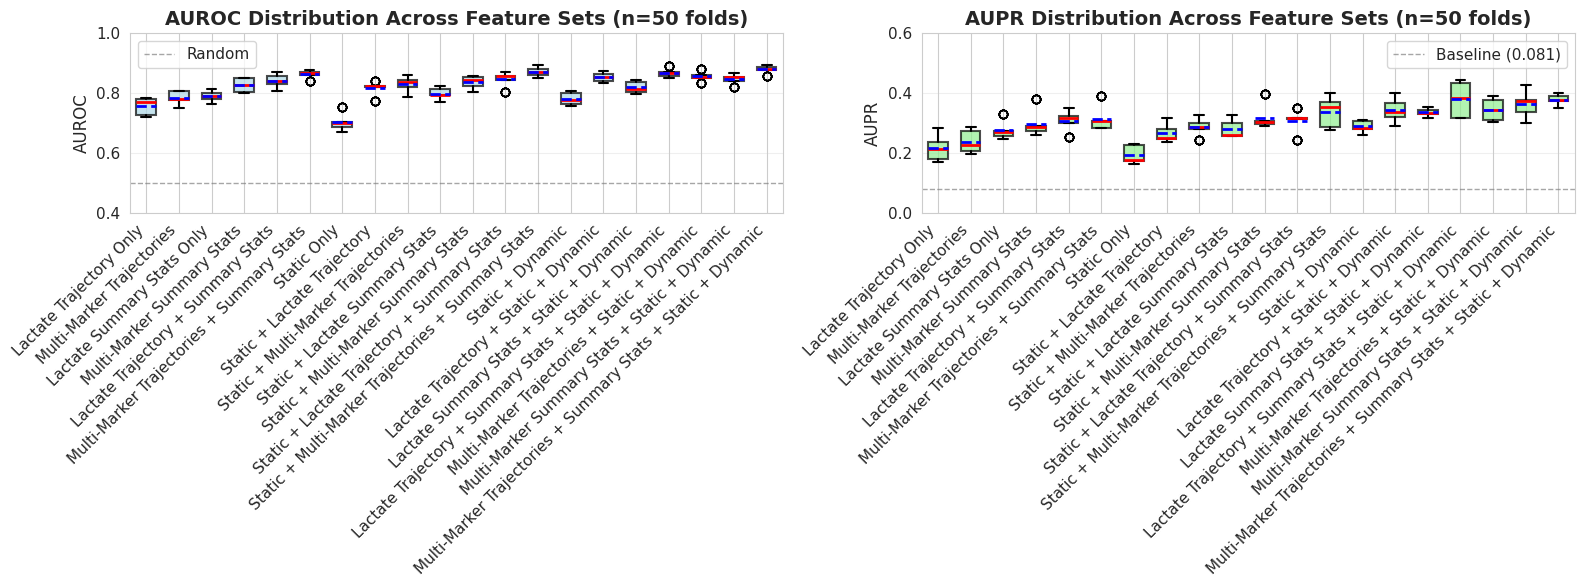


PAIRWISE STATISTICAL COMPARISONS (Wilcoxon Signed-Rank Test)
Comparison                                                   AUROC p      Sig   AUPR p       Sig  
--------------------------------------------------------------------------------
Note: * p<0.05, ** p<0.01, *** p<0.001
Wilcoxon test is appropriate here as models are evaluated on identical CV folds (paired data)


In [26]:
# Boxplot visualization with statistical significance testing (using shared utilities)
# Define key pairwise comparisons
pairwise_comparisons = [
]

feature_names = list(comparison_results.keys())
n_folds_total = len(comparison_results[feature_names[0]]['roc_auc'])

# Use shared utility function for boxplots with significance testing
fig, (ax1, ax2) = plot_boxplots_with_stats(
    comparison_results=comparison_results,
    outcome_df=outcome_df,
    target_col='target_septic_shock',
    pairs_to_compare=pairwise_comparisons,
    n_folds_total=n_folds_total,
    roc_ylim=(0.4, 1.),
    ap_ylim=(0.0, 0.6)
)
plt.savefig('../../results/mimic/sepsis/model_comparison_boxplots_significance.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: model_comparison_boxplots_significance.png")
plt.show()

# Print detailed statistical comparisons using shared utility
print_statistical_comparisons(
    comparison_results=comparison_results,
    pairs_to_compare=pairwise_comparisons
)


✓ Saved: model_comparison_curves.png


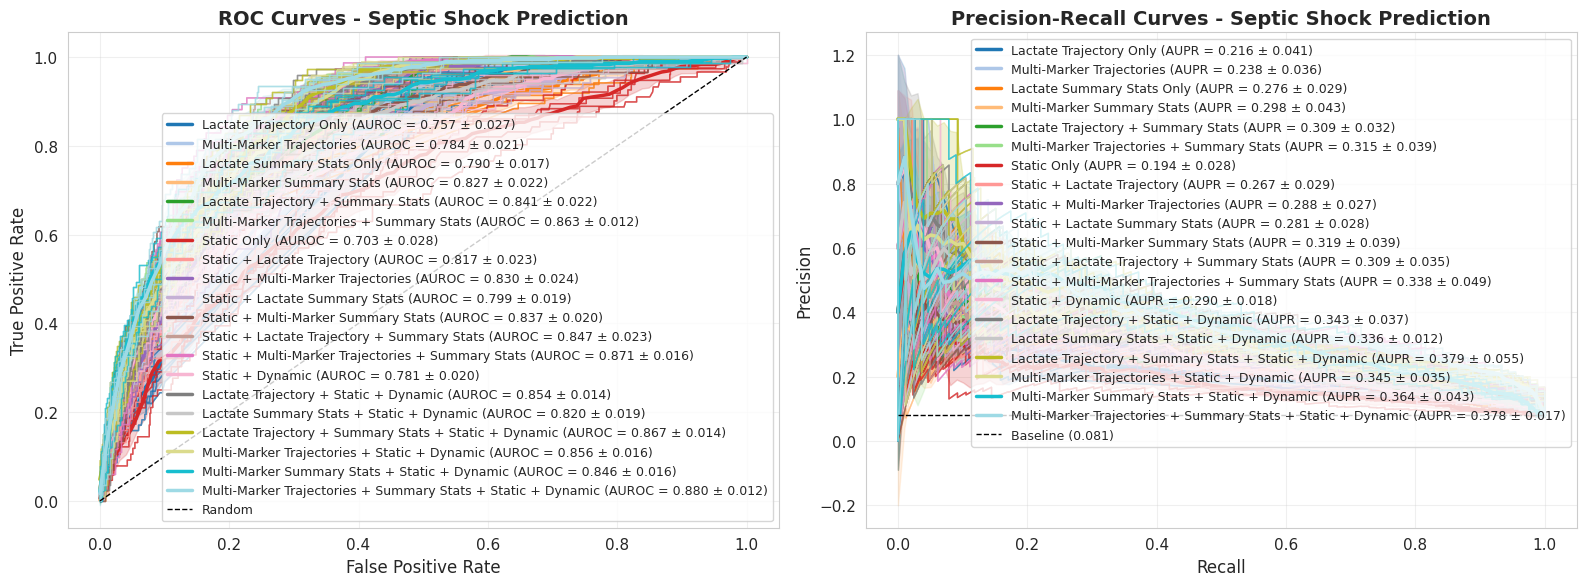


📊 Summary:
    - Multi-marker trajectories capture organ dysfunction progression
    - Comprehensive model includes perfusion, infection, coagulation, and organ function
    - Enables timely intervention (fluids, antibiotics, vasopressors, organ support)


In [27]:
# ROC & PR Curves - Using shared utility function
fig, (ax1, ax2) = plot_roc_pr_curves(
    comparison_results=comparison_results,
    outcome_df=outcome_df,
    target_col='target_septic_shock',
    color_scheme='tab20'
)

# Update titles for sepsis context
ax1.set_title('ROC Curves - Septic Shock Prediction', fontsize=14, fontweight='bold')
ax2.set_title('Precision-Recall Curves - Septic Shock Prediction', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../../results/mimic/sepsis/model_comparison_curves.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: model_comparison_curves.png")
plt.show()

# Summary and clinical interpretation
print(f"\n📊 Summary:")
print(f"    - Multi-marker trajectories capture organ dysfunction progression")
print(f"    - Comprehensive model includes perfusion, infection, coagulation, and organ function")
print(f"    - Enables timely intervention (fluids, antibiotics, vasopressors, organ support)")

In [28]:
best_model = max(comparison_results.items(), key=lambda x: np.mean(x[1]['roc_auc']))

print("\n✓ Multi-marker sepsis progression analysis complete!")
print(f"\n  Key Results:")
print(f"    - Dataset: {len(prediction_clean):,} prediction windows")
print(f"    - Patients: {groups.nunique():,} sepsis admissions")
print(f"    - Event rate: {y.mean():.1%}")
print(f"    - Best model: {best_model[0]} (AUC={np.mean(best_model[1]['roc_auc']):.3f})")
print(f"\n  Feature Engineering:")
print(f"    - Trajectory markers: Lactate + WBC + Platelets")
print(f"    - Vitals: HR, MAP, Temp, RR, SpO2")
print(f"    - Labs: Creatinine, Bilirubin, INR, pH, Bicarb")
print(f"    - Clinical flags: 9 SIRS/organ dysfunction indicators")
print(f"\n  Clinical Impact:")
print(f"    - Early detection of septic shock (48h ahead)")
print(f"    - Multi-marker trajectories capture organ dysfunction progression")
print(f"    - Comprehensive model includes perfusion, infection, coagulation, and organ function")
print(f"    - Enables timely intervention (fluids, antibiotics, vasopressors, organ support)")


✓ Multi-marker sepsis progression analysis complete!

  Key Results:
    - Dataset: 5,090 prediction windows
    - Patients: 1,175 sepsis admissions
    - Event rate: 8.1%
    - Best model: Multi-Marker Trajectories + Summary Stats + Static + Dynamic (AUC=0.880)

  Feature Engineering:
    - Trajectory markers: Lactate + WBC + Platelets
    - Vitals: HR, MAP, Temp, RR, SpO2
    - Labs: Creatinine, Bilirubin, INR, pH, Bicarb
    - Clinical flags: 9 SIRS/organ dysfunction indicators

  Clinical Impact:
    - Early detection of septic shock (48h ahead)
    - Multi-marker trajectories capture organ dysfunction progression
    - Comprehensive model includes perfusion, infection, coagulation, and organ function
    - Enables timely intervention (fluids, antibiotics, vasopressors, organ support)
